<a href="https://colab.research.google.com/github/lejuin/aidl_fingerspelling/blob/main/notebooks/Run_git_code_in_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import git repo

In [78]:
#!git clone https://github.com/lejuin/fingerspelling_asl.git
!git clone -b track_val_loss https://github.com/lejuin/fingerspelling_asl.git

Cloning into 'fingerspelling_asl'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 104 (delta 37), reused 95 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 492.79 KiB | 32.85 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
!pip install -r fingerspelling_asl/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 140.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import sys
sys.path.insert(0,'fingerspelling_asl')

In [3]:
import pandas as pd
from google.colab import userdata

# Setup for Colab

In [5]:
!curl ipinfo.io

{
  "ip": "34.124.180.238",
  "hostname": "238.180.124.34.bc.googleusercontent.com",
  "city": "Singapore",
  "region": "Singapore",
  "country": "SG",
  "loc": "1.2897,103.8501",
  "org": "AS396982 Google LLC",
  "postal": "018989",
  "timezone": "Asia/Singapore",
  "readme": "https://ipinfo.io/missingauth"
}

## Configuration to load from bucket

In [6]:
from google.colab import auth
PROJECT_ID = "firststepsgc"
#PROJECT_ID = "buoyant-purpose-479417-t8"
auth.authenticate_user(project_id=PROJECT_ID)

BUCKET_NAME = "aidl_asl_datasets"

In [48]:
args_dict = {
  'data_dir': f"gs://{BUCKET_NAME}/asl-fingerspelling",
  'train_csv': "train.csv",
  'run_name': None,
  'logdir':"artifacts/logs",
  'max_frames':160,
  'epochs':5,
  'batch_size':16,
  'lr':1e-3,
  'hidden_dim':128,
  'val_ratio':0.2,
  'seed':42,
  'train_size':200,
  'val_size':200,
  'max_phrase_len':0,
  'overfit_subset':0,
  'use_wandb':True,
  'wandb_project':"fingerspelling_asl",
  'wandb_entity':None,
  'wandb_run_name':None,
  'wandb_mode':"online",
  'wandb_tags':""
}

NameError: name 'BUCKET_NAME' is not defined

## To download and run locally

In [8]:
!pip install kagglehub==1.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 23.9 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [5]:
import kagglehub
print(kagglehub.__version__)

1.0.0


In [6]:
from pathlib import Path

In [7]:
train_path =  kagglehub.competition_download('asl-fingerspelling', path="train.csv")
voc_path =  kagglehub.competition_download('asl-fingerspelling', path="character_to_prediction_index.json")

In [ ]:
#supp_path =  kagglehub.competition_download('asl-fingerspelling', path="supplemental_metadata.csv")

In [8]:
train_pdf =pd.read_csv(train_path)
print("train_pdf.shape", train_pdf.shape)
train_pdf.head()

train_pdf.shape (67208, 5)


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


In [ ]:
# supp_pdf = pd.read_csv(supp_path)
# print("supp_pdf.shape", supp_pdf.shape)
# supp_pdf.head()

In [10]:
compet_dir = Path(train_path).parent
#list((compet_dir / "train_landmarks").glob("*"))

[]

In [11]:
#downloaded_files = [filename.name for filename in gc_bucket.list_blobs()]
#missing_files = [f for f in train_pdf['path'].unique() if f"asl-fingerspelling/{f}" not in bucket_files]
missing_files = [f for f in train_pdf['path'].unique()]
print(f"Number of missing files: {len(missing_files)}")
missing_files[:5]

Number of missing files: 68


['train_landmarks/5414471.parquet',
 'train_landmarks/105143404.parquet',
 'train_landmarks/128822441.parquet',
 'train_landmarks/149822653.parquet',
 'train_landmarks/152029243.parquet']

In [12]:
landmark_paths = {}

#file_id = 5414471
for file_id in [5414471, 105143404]:
  landmark_paths[file_id] = kagglehub.competition_download('asl-fingerspelling', path=f'train_landmarks/{file_id}.parquet')

100%|██████████| 1.28G/1.28G [01:07<00:00, 20.5MB/s]

Extracting zip of 5414471.parquet...


100%|██████████| 1.26G/1.26G [01:06<00:00, 20.4MB/s]

Extracting zip of 105143404.parquet...


In [104]:
# To download data and load locally
args_dict = {
  'data_dir': compet_dir,
  'train_csv': "train.csv",
  'run_name': "single_file_lstm",
  'logdir':"artifacts/logs",
  'max_frames':160,
  'epochs':15,
  'batch_size':8,
  'lr':1e-3,
  'weight_decay':1e-4,
  'hidden_dim':64,
  'proj_dim': 32,
  #'tcn_kernels': "3,3,3",
  'rnn_layers': 2,
  'rnn_type': 'lstm',
  'val_ratio':0.2,
  'seed':42,
  'train_size':200,
  'val_size':200,
  'use_supplemental': False,
  'max_phrase_len':20,
  'overfit_subset':0,
  'eval_train_metrics': True,
  'use_wandb':True,
  'wandb_project':"fingerspelling_asl",
  'wandb_entity':None,
  'wandb_run_name':None,
  'wandb_mode':"online",
  'wandb_tags':"lstm,bidir,tiny_subset,letters_only"
}

### [temp]: attemp to pre-compute dataset

In [ ]:
tmp = df.head().copy()
tmp

,path,file_id,sequence_id,participant_id,phrase
16,train_landmarks/5414471.parquet,5414471,1817362238,231,leona owens
19,train_landmarks/5414471.parquet,5414471,1817438012,202,kati castro
30,train_landmarks/5414471.parquet,5414471,1817781680,254,jami mcfarland
53,train_landmarks/5414471.parquet,5414471,1818444969,227,tomeka salinas
81,train_landmarks/5414471.parquet,5414471,1819369909,141,polcathejourney


In [ ]:
from src.data.dataset import read_right_hand_sequence

In [ ]:
x = read_right_hand_sequence(landmark_paths[file_id], 1817362238)

In [ ]:
type(x)

numpy.ndarray

In [ ]:
x.shape

(78, 63)

In [ ]:
import numpy as np

# Save the array 'x' to a .npy file
np.save('x_data.npy', x)
print("Array 'x' saved to x_data.npy")

# To load the array back:
loaded_x = np.load('x_data.npy')
print("Array loaded from x_data.npy with shape:", loaded_x.shape)
print("Type of loaded array:", type(loaded_x))

Array 'x' saved to x_data.npy
Array loaded from x_data.npy with shape: (78, 63)
Type of loaded array: <class 'numpy.ndarray'>


In [ ]:
!ls -lh

total 36K
drwxr-xr-x 4 root root 4.0K Mar 10 22:51 artifacts
drwxr-xr-x 6 root root 4.0K Mar 10 21:04 fingerspelling_asl
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
drwxr-xr-x 4 root root 4.0K Mar 10 23:12 wandb
-rw-r--r-- 1 root root  20K Mar 10 23:39 x_data.npy


## Preparing args

In [105]:
# setting params
class Args:
    def __init__(self, dict_args):
        for key, value in dict_args.items():
            setattr(self, key, value)

args = Args(args_dict)

args.train_csv

'train.csv'

In [15]:
from src.train import *

In [16]:
import os
import json
import argparse
#from fsspec.implementations.local import LocalFileSystem
from datetime import datetime
from typing import List, Tuple

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import re

try:
    import wandb
except ImportError:
    wandb = None

from src.models.tcn_bilstm import TCNBiRNN
from src.models.embedded_rnn import EmbeddedRNN
from src.data.dataset import ASLRightHandDataset, collate_fn
from src.data.vocab import build_ctc_vocab, encode_phrase
from src.utils.metrics import evaluate_metrics, ctc_greedy_decode

# Reproduce main function

In [ ]:
# from_bucket branch version
from fsspec.implementations.local import LocalFileSystem
from src.utils.filesystem import get_filesystem, join_path

fs = get_filesystem(args.data_dir)
train_csv = args.train_csv

if not os.path.isabs(train_csv):
    train_csv = join_path(fs, args.data_dir, train_csv)
vocab_json =join_path(fs,args.data_dir, "character_to_prediction_index.json")
landmarks_dir = join_path(fs, args.data_dir, "train_landmarks")

if not fs.exists(train_csv):
    raise FileNotFoundError(f"Missing {train_csv}")
if not fs.exists(vocab_json):
    raise FileNotFoundError(f"Missing {vocab_json}")
if not fs.isdir(landmarks_dir):
    raise FileNotFoundError(f"Missing folder {landmarks_dir}")


In [106]:
# main branch version
train_csv = args.train_csv
if not os.path.isabs(train_csv):
    train_csv = os.path.join(args.data_dir, train_csv)
vocab_json = os.path.join(args.data_dir, "character_to_prediction_index.json")
landmarks_dir = os.path.join(args.data_dir, "train_landmarks")

if not os.path.exists(train_csv):
    raise FileNotFoundError(f"Missing {train_csv}")
if not os.path.exists(vocab_json):
    raise FileNotFoundError(f"Missing {vocab_json}")
if not os.path.isdir(landmarks_dir):
    raise FileNotFoundError(f"Missing folder {landmarks_dir}")

In [107]:
 # Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [108]:
# Load vocab mapping (char -> id) in CTC-compatible form
letter_to_int, int_to_letter, blank_id = build_ctc_vocab(vocab_json) #, fs)

In [109]:
# Load train.csv
df = pd.read_csv(train_csv)
required_cols = {"file_id", "sequence_id", "participant_id", "phrase"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"train.csv is missing columns: {missing}")

df.shape

(67208, 5)

In [110]:
# Filter by parquets you actually downloaded
have_ids = existing_file_ids(landmarks_dir) #, fs)
if not have_ids:
    raise ValueError(
        f"No parquet files found in {landmarks_dir}. "
        f"Download a few like 0.parquet, 1.parquet, etc."
    )
df = df[df["file_id"].isin(have_ids)].copy()
print(f"Rows after filtering to available parquets ({len(have_ids)} file_ids): {len(df)}")

Rows after filtering to available parquets (2 file_ids): 2000


In [111]:
_clean_re = re.compile(r'^[a-z ]+$')
df["phrase"] = df["phrase"].astype(str).str.lower().str.strip()
df = df[df["phrase"].apply(lambda x: bool(_clean_re.match(x)) and len(x) > 0)].copy()
print(f"Rows after filtering to letters-only phrases: {len(df)}")

Rows after filtering to letters-only phrases: 246


In [112]:
from src.data.dataset import read_right_hand_sequence, count_valid_frames
print("Pre-filtering sequences with no right-hand landmarks...")
valid_mask = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking landmarks", leave=False):
    fid = int(row["file_id"])
    sid = int(row["sequence_id"])
    lm_dir = landmarks_dir
    if "_landmarks_dir" in row.index:
        lm_dir = row["_landmarks_dir"]
    ppath = os.path.join(lm_dir, f"{fid}.parquet")
    if not os.path.exists(ppath):
        valid_mask.append(False)
        continue
    X_raw = read_right_hand_sequence(ppath, sid)
    n_valid = count_valid_frames(X_raw)
    valid_mask.append(n_valid > 0)
df = df[valid_mask].copy()
print(f"Rows after filtering no-data sequences: {len(df)}")

Pre-filtering sequences with no right-hand landmarks...


Rows after filtering no-data sequences: 210


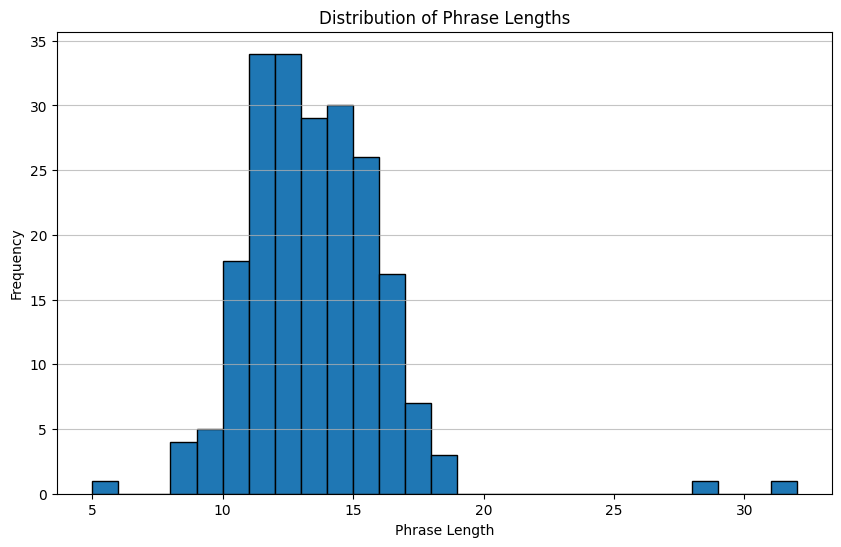

In [113]:
import matplotlib.pyplot as plt

phrase_lengths = df["phrase"].astype(str).str.len()

plt.figure(figsize=(10, 6))
plt.hist(phrase_lengths, bins=range(min(phrase_lengths), max(phrase_lengths) + 2), edgecolor='black')
plt.title('Distribution of Phrase Lengths')
plt.xlabel('Phrase Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [114]:
if args.max_phrase_len > 0:
    df = df[df["phrase"].astype(str).str.len() <= args.max_phrase_len].copy()
    print(f"Rows after filtering by max_phrase_len={args.max_phrase_len}: {len(df)}")
    if len(df) == 0:
        raise ValueError("No rows left after max_phrase_len filtering.")

Rows after filtering by max_phrase_len=20: 208


In [115]:
if args.overfit_subset > 0:
    n_subset = min(args.overfit_subset, len(df))
    overfit_df = df.sample(n=n_subset, random_state=args.seed).copy()
    overfit_df["encoded"] = overfit_df["phrase"].apply(lambda x: encode_phrase(str(x), letter_to_int))
    train_df = overfit_df.copy()
    val_df = overfit_df.copy()
    print(f"Overfit mode enabled: using same {n_subset} samples for train and val")
else:
    # Split by participant_id
    train_df, val_df = split_by_participant(df, val_ratio=args.val_ratio, seed=args.seed)

    # Encode targets
    train_df["encoded"] = train_df["phrase"].apply(lambda x: encode_phrase(str(x), letter_to_int))
    val_df["encoded"] = val_df["phrase"].apply(lambda x: encode_phrase(str(x), letter_to_int))

    # Sample small subsets for local dev
    if args.train_size and args.train_size < len(train_df):
        train_df = train_df.sample(args.train_size, random_state=args.seed)
    if args.val_size and args.val_size < len(val_df):
        val_df = val_df.sample(args.val_size, random_state=args.seed)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

Train samples: 177 | Val samples: 31


In [116]:
# Datasets / loaders
#train_ds = ASLRightHandDataset(train_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames)
#val_ds = ASLRightHandDataset(val_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames)
train_ds = ASLRightHandDataset(train_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames, use_per_row_dir=args.use_supplemental, training=True)
val_ds = ASLRightHandDataset(val_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames, use_per_row_dir=args.use_supplemental, training=False)

train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [117]:
# Model — 63 landmarks + 63 delta features = 126
input_dim = 126
# output_dim must match max id + 1 (including blank=0)
output_dim = max(int_to_letter.keys()) + 1

model = EmbeddedRNN(input_dim, args.hidden_dim, output_dim).to(device)

In [118]:
criterion = nn.CTCLoss(blank=blank_id, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3,
)

In [119]:
# Tracking setup
run_name = args.run_name or datetime.now().strftime("run_%Y%m%d_%H%M%S")

# TensorBoard
log_path = os.path.join(args.logdir, run_name)
os.makedirs(log_path, exist_ok=True)
writer = SummaryWriter(log_path)
print(f"TensorBoard logdir: {log_path}")

TensorBoard logdir: artifacts/logs/single_file_lstm


In [120]:
run_name = "single_file_lstm_5"

In [121]:
import os

# Set the WANDB_API_KEY environment variable
# You should set your API key in Colab secrets under the name 'WANDB_API_KEY'
if 'WANDB_API_KEY' not in os.environ:
    os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')

wandb_enabled = args.use_wandb and args.wandb_mode != "disabled"
if args.use_wandb and wandb is None:
    raise ImportError("wandb is not installed. Run: pip install wandb")

if wandb_enabled:
    # Initialize wandb by logging in with the API key
    # This prevents interactive prompts for the API key
    wandb.login(key=os.environ.get('WANDB_API_KEY'))

    wandb.init(
        project=args.wandb_project,
        entity=args.wandb_entity,
        name=args.wandb_run_name or run_name,
        config=vars(args),
        mode=args.wandb_mode,
        tags=parse_wandb_tags(args.wandb_tags)
    )

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [122]:
# X, Y, in_lens, tar_lens = next(iter(train_loader))
# print(X.shape)

# model(X.to(device), in_lens)

In [123]:
global_step = 0
best_val_cer = float("inf")
for epoch in range(args.epochs):
    model.train()
    losses = []
    blank_ratios = []
    in_tar_ratios = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{args.epochs}", leave=False)

    for batch in pbar:
        if batch is None:
            continue
        X, Y, in_lens, tar_lens = batch
        X = X.to(device)

        optimizer.zero_grad()
        log_probs = model(X, in_lens)  # (T, B, C)

        loss = criterion(log_probs, Y, in_lens, tar_lens)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"WARNING: skipping batch with loss={loss.item()}")
            optimizer.zero_grad()
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Simple diagnostics: blank-token dominance and input/target length ratio.
        with torch.no_grad():
            pred_ids = torch.argmax(log_probs, dim=2)  # (T, B)
            blank_mask = (pred_ids == blank_id).float()
            blank_ratios.append(float(blank_mask.mean().item()))
            ratio_vals = (in_lens.float() / tar_lens.float().clamp_min(1.0)).detach().cpu()
            in_tar_ratios.append(float(ratio_vals.mean().item()))

        loss_val = float(loss.item())
        losses.append(loss_val)

        writer.add_scalar("loss/train_step", loss_val, global_step)
        if wandb_enabled:
            wandb.log({"loss/train_step": loss_val, "global_step": global_step}, step=global_step)

        global_step += 1
        pbar.set_postfix(loss=loss_val)

    mean_train_loss = float(sum(losses) / max(1, len(losses)))
    mean_blank_ratio = float(sum(blank_ratios) / max(1, len(blank_ratios)))
    mean_in_tar_ratio = float(sum(in_tar_ratios) / max(1, len(in_tar_ratios)))
    writer.add_scalar("loss/train", mean_train_loss, epoch)
    writer.add_scalar("diag/blank_ratio_pred", mean_blank_ratio, epoch)
    writer.add_scalar("diag/input_target_len_ratio", mean_in_tar_ratio, epoch)
    print(f"Epoch {epoch + 1}: train loss={mean_train_loss:.4f}")

    metrics_train = None
    if args.eval_train_metrics:
        metrics_train = evaluate_metrics(
            model,
            train_loader,
            int_to_letter=int_to_letter,
            device=device,
            blank_id=blank_id,
        )
        writer.add_scalar("cer/train", metrics_train["cer"], epoch)
        writer.add_scalar("wer/train", metrics_train["wer"], epoch)
        writer.add_scalar("sequence_accuracy/train", metrics_train["sequence_accuracy"], epoch)
        writer.add_scalar("avg_edit_distance/train", metrics_train["avg_edit_distance"], epoch)

    # Validation metrics
    metrics_val = evaluate_metrics(
        model,
        val_loader,
        int_to_letter=int_to_letter,
        device=device,
        blank_id=blank_id,
        loss_fn=criterion,
    )
    writer.add_scalar("loss/val", metrics_val["loss"], epoch)
    writer.add_scalar("cer/val", metrics_val["cer"], epoch)
    writer.add_scalar("wer/val", metrics_val["wer"], epoch)
    writer.add_scalar("sequence_accuracy/val", metrics_val["sequence_accuracy"], epoch)
    writer.add_scalar("avg_edit_distance/val", metrics_val["avg_edit_distance"], epoch)

    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("lr", current_lr, epoch)
    #scheduler.step(mean_train_loss)
    scheduler.step(metrics_val["loss"])

    if wandb_enabled:
        payload = {
            "epoch": epoch + 1,
            "loss/train": mean_train_loss,
            "loss/val": metrics_val["loss"],
            "diag/blank_ratio_pred": mean_blank_ratio,
            "diag/input_target_len_ratio": mean_in_tar_ratio,
            "cer/val": metrics_val["cer"],
            "wer/val": metrics_val["wer"],
            "sequence_accuracy/val": metrics_val["sequence_accuracy"],
            "avg_edit_distance/val": metrics_val["avg_edit_distance"],
            "global_step": global_step,
            "lr": current_lr,
        }
        if metrics_train is not None:
            payload.update(
                {
                    "cer/train": metrics_train["cer"],
                    "wer/train": metrics_train["wer"],
                    "sequence_accuracy/train": metrics_train["sequence_accuracy"],
                    "avg_edit_distance/train": metrics_train["avg_edit_distance"],
                }
            )
        wandb.log(payload, step=global_step)

    if metrics_train is not None:
        print(
            f"Epoch {epoch + 1}: "
            f"train CER={metrics_train['cer']:.4f} | "
            f"WER={metrics_train['wer']:.4f} | "
            f"ExactMatch={metrics_train['sequence_accuracy']:.4f} | "
            f"AvgEditDist={metrics_train['avg_edit_distance']:.4f}"
        )
    print(
        f"Epoch {epoch + 1}: "
        f"lr={current_lr:.4f} | "
        f"diag blank_ratio_pred={mean_blank_ratio:.4f} | "
        f"input/target ratio={mean_in_tar_ratio:.2f}"
    )

    print(
        f"Epoch {epoch + 1}: "
        f"val loss={metrics_val['loss']:.4f} | "
        f"val CER={metrics_val['cer']:.4f} | "
        f"WER={metrics_val['wer']:.4f} | "
        f"ExactMatch={metrics_val['sequence_accuracy']:.4f} | "
        f"AvgEditDist={metrics_val['avg_edit_distance']:.4f}"
    )

    # Save best checkpoint (by val CER)
    if metrics_val["cer"] < best_val_cer:
        best_val_cer = metrics_val["cer"]
        ckpt_path = os.path.join("artifacts", "models", f"{run_name}_best.pt")
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": vars(args),
            },
            ckpt_path,
        )
        print(f"  -> Saved best model (val CER={best_val_cer:.4f})")

    # Save latest checkpoint (for resuming)
    ckpt_path = os.path.join("artifacts", "models", f"{run_name}_latest.pt")
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": vars(args),
        },
        ckpt_path,
    )


Epoch 1: train loss=8.4567
Epoch 1: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8881
Epoch 1: lr=0.0010 | diag blank_ratio_pred=0.3685 | input/target ratio=5.34
Epoch 1: val loss=3.8312 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545
  -> Saved best model (val CER=1.0000)


Epoch 2: train loss=3.3952
Epoch 2: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8690
Epoch 2: lr=0.0010 | diag blank_ratio_pred=0.4257 | input/target ratio=5.32
Epoch 2: val loss=3.3469 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 3: train loss=3.3461
Epoch 3: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8601
Epoch 3: lr=0.0010 | diag blank_ratio_pred=0.4108 | input/target ratio=5.17
Epoch 3: val loss=3.3473 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 4: train loss=3.3282
Epoch 4: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8881
Epoch 4: lr=0.0010 | diag blank_ratio_pred=0.4237 | input/target ratio=5.32
Epoch 4: val loss=3.3345 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 5: train loss=3.3170
Epoch 5: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8944
Epoch 5: lr=0.0010 | diag blank_ratio_pred=0.4123 | input/target ratio=5.21
Epoch 5: val loss=3.3244 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


...

Epoch 11: train loss=3.1417
Epoch 11: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8671
Epoch 11: lr=0.0010 | diag blank_ratio_pred=0.4290 | input/target ratio=5.37
Epoch 11: val loss=3.0886 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 12: train loss=3.0460
Epoch 12: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8750
Epoch 12: lr=0.0010 | diag blank_ratio_pred=0.4165 | input/target ratio=5.23
Epoch 12: val loss=3.0775 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 13: train loss=3.0549
Epoch 13: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.9155
Epoch 13: lr=0.0010 | diag blank_ratio_pred=0.4156 | input/target ratio=5.21
Epoch 13: val loss=3.0594 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 14: train loss=3.0441
Epoch 14: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8944
Epoch 14: lr=0.0010 | diag blank_ratio_pred=0.4360 | input/target ratio=5.44
Epoch 14: val loss=3.0397 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


Epoch 15: train loss=3.0734
Epoch 15: train CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.8521
Epoch 15: lr=0.0010 | diag blank_ratio_pred=0.4021 | input/target ratio=5.06
Epoch 15: val loss=3.0407 | val CER=1.0000 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=13.4545


In [125]:
if wandb_enabled:
    log_examples_to_wandb(
        model=model,
        dataloader=val_loader,
        int_to_letter=int_to_letter,
        device=device,
        blank_id=blank_id,
        global_step=global_step,
        split_name="val",
        n_examples=5,
    )

Logging 5 GT/PRED examples (val):
[1] GT: vivian nicholson
    PRED: 
[2] GT: rickie schroeder
    PRED: 
[3] GT: yonkers new york
    PRED: 
[4] GT: mariel tucker
    PRED: 
[5] GT: tremaine mcintyre
    PRED: 


In [126]:
writer.close()
if wandb_enabled:
    wandb.finish()

avg_edit_distance/train,▅▃▂▅▆█▃█▄▁▃▄█▆▁
avg_edit_distance/val,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cer/train,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cer/val,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
diag/blank_ratio_pred,▁▇▅▇▆▆▇▆▆▆▇▆▆█▄
diag/input_target_len_ratio,▆▆▃▆▄▅▇▄▆▅▇▄▄█▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██
loss/train,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/train_step,▇█▂▁▂▂▁▁▂▁▁▁▁▁▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...
